# Deep Learning Project Work

In this project, I will explore the benchmarking of DINO models for an image classification task. The models to be evaluated include:

- (?) DINOv2 (facebook/dinov2) (?)
- DINOv2 base with registers (facebook/dinov2-with-registers-base)
- DINOv3 base (facebook/dinov3-vitb16-pretrain-lvd1689m)

The dataset on which the models will be trained and evaluated is the dataset available at the [link](https://zenodo.org/records/10137731) relative to [this paper](https://onlinelibrary.wiley.com/doi/10.1111/gcb.17078), regarding micrometeorological conditions across 49 wildlife cameras in South Africa's Maloti-Drakensberg and the Swiss Alps, with classifications for **overcast**, **sunshine**, **hail**, and **snow** conditions.

In the original paper, 

In [1]:
import numpy as np
import pandas as pd
import os
import random
from PIL import Image, ImageFile

import seaborn as sns
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import interact
from tqdm import tqdm
from collections import defaultdict
from typing import Tuple
from concurrent.futures import ProcessPoolExecutor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch.optim as optim

import timm

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED=42

DATASET_PATH = "/mnt/synas/ngb/AI_DATASETS/zenodo_10137731_weather_ct/"

IMAGES_METADATA_CSV = DATASET_PATH + "image_metadata.csv"

IMAGES_DIR = DATASET_PATH + "images/"

IMAGES_METADATA_CSV_LOCAL = "image_metadata_local_paths.csv"

IMAGES_DIR_LOCAL = "dataset_local"



CLASS_NAMES = [
    "background",
    "sunshine",
    "snow",
    "hail",
]

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(SEED)

## Analyzing dataset structure

Attached to the dataset there are CSV files with metadata for images and cameras. The main file for images is `image_data.csv`, with these columns, not all of which are needed/useful for model training:

- `DatasetOutFileName`: image file name.
- `label_sample`: sampling strategy used to select the image (not needed for model training).
- `Region`: camera region (e.g. Maloti-Drakensberg `ZA` or Swiss Alps `CH`).
- `cam`: unique camera ID that captured the image.
- `DateTimeOriginal`: original date/time from image metadata (raw format, may contain colons).
- `DateTime`: reformatted date/time (standardized representation).
- `DOY`: day of year ($1–366$).
- `Hour`: hour of capture ($0–23$).
- `Minute`: minute of capture ($0–59$).
- `Temperature`: ambient temperature recorded by the sensor at capture time.
- `Flash`: whether flash fired ($1$) or not ($0$).
- `ExposureTime`: shutter exposure time in seconds (decimal).
- `weather`: numeric weather class label (target for the model, e.g. 0–3).
- `weather_desc`: textual weather class (e.g. `background`, `sunshine`, `hail`, `snow`).
- `cis_fold`: fold index ($0–4$) for **Cis fivefold cross‑validation**, a within‑domain, image‑level random split where images from all cameras are randomly assigned to folds. Folds are mutually exclusive, stratified by the four study sites, and each fold is iteratively used as validation while the other four form the training set.
- `trans_fold`: fold index ($0–4$) for **Trans fivefold cross‑validation**, a camera‑level split where entire cameras (all their images) are assigned to folds so that no camera appears in both training and validation. Folds are mutually exclusive and stratified by the four study sites.
- `holdout`: boolean indicator (`TRUE` if reserved exclusively for the final test set).
- `cis_prod_fold`: alternative Cis fold variant (also a fivefold, site‑stratified Cis split) used for production/alternate experiment splits or final model selection; similar semantics to `cis_fold` but intended for deployment/production evaluation.


In [2]:
df_metadata_images = pd.read_csv(IMAGES_METADATA_CSV)
df_metadata_images.head()

,DatasetOutFileName,label_sample,Region,cam,DateTimeOriginal,DateTime,DOY,Hour,Minute,Temperature,Flash,ExposureTime,weather,weather_desc,cis_fold,trans_fold,holdout,cis_prod_fold
0,000001.JPG,systematic,ZA,SA16,2022:01:12 21:01:12,12/01/2022 21:01,12,21,1,10,1,0.065986,0,background,2,4,False,4
1,000002.JPG,strategic,ZA,SA07,2021:12:25 03:03:27,25/12/2021 03:03,359,3,3,2,1,0.065986,3,hail,4,2,False,1
2,000003.JPG,systematic,ZA,SA06,2022:04:01 15:00:27,01/04/2022 15:00,91,15,0,6,0,0.004672,1,sunshine,1,1,False,1
3,000004.JPG,strategic,CH,C02,2021:09:04 01:00:01,04/09/2021 01:00,247,1,0,7,1,0.065986,0,background,6,6,True,5
4,000005.JPG,systematic,CH,C17,2021:08:31 09:01:31,31/08/2021 09:01,243,9,1,5,0,0.002625,1,sunshine,2,3,False,5


## Utils functions for splits creation

In [3]:
def is_holdout(df: pd.DataFrame, holdout_col: str = 'holdout') -> pd.Series:
    '''
    Function to determine holdout rows in DataFrame.
    Inputs:
    - df: input DataFrame
    Outputs:
    - pd.Series of booleans indicating holdout status
    '''
    s = df.get(holdout_col)
    if s is None:
        return pd.Series([False] * len(df), index=df.index)
    if s.dtype == bool:
        return s.fillna(False)
    s_str = s.astype(str).str.upper()
    return s_str == 'TRUE'

def make_splits(df: pd.DataFrame, fold_col: str, fold_index: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    '''
    Function to split DataFrame into train/val/test sets according to specified fold column and index.
    Inputs:
    - df: input DataFrame
    - fold_col: name of the column containing fold assignments
    - fold_index: index of the fold to use as validation set
    Outputs:
    - train_df: training set DataFrame
    - val_df: validation set DataFrame
    - test_df: test set DataFrame
    '''
    df_cp = df.copy()

    holdout_mask = is_holdout(df_cp)
    test_df = df_cp[holdout_mask].reset_index(drop=True)
    df_no_holdout = df_cp[~holdout_mask].reset_index(drop=True)

    if fold_col not in df_no_holdout.columns:
        raise KeyError(f'Fold column {fold_col} not in DataFrame columns: {list(df_no_holdout.columns)}')
    
    val_mask = df_no_holdout[fold_col] == fold_index
    val_df = df_no_holdout[val_mask].reset_index(drop=True)
    train_df = df_no_holdout[~val_mask].reset_index(drop=True)

    return train_df, val_df, test_df

# NOTE: not used to be consistent with the paper approach
def make_cis_splits(df: pd.DataFrame, fold_index: int = 0):
    return make_splits(df, 'cis_fold', fold_index)

# NOTE: not used to be consistent with the paper approach
def make_trans_splits(df: pd.DataFrame, fold_index: int = 0):
    return make_splits(df, 'trans_fold', fold_index)

def make_cis_prod_splits(df: pd.DataFrame, fold_index: int = 0):
    return make_splits(df, 'cis_prod_fold', fold_index)

Total images: 8953
Total cameras: 49


Top 10 cameras by image count:


cam
C20     463
C18     463
C22     462
C21     426
C19     319
C24     293
C17     288
SA04    245
SA02    245
SA03    245
Name: count, dtype: int64

Worst 10 cameras by image count:


cam
C05    65
C08    64
C12    53
C09    25
C03    24
C04    24
C11    24
C07    24
C14    23
C06    14
Name: count, dtype: int64

--------------------
Validation fold distribution:


...


FOLD 5
Train size: 6327


background    0.612613
sunshine      0.179390
snow          0.111111
hail          0.096886
Name: proportion, dtype: float64

Val size: 1293


background    0.642691
sunshine      0.161640
snow          0.102088
hail          0.093581
Name: proportion, dtype: float64

--------------------
Temporal distributions:


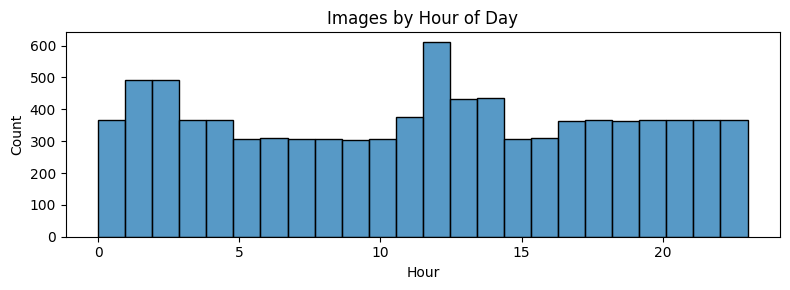

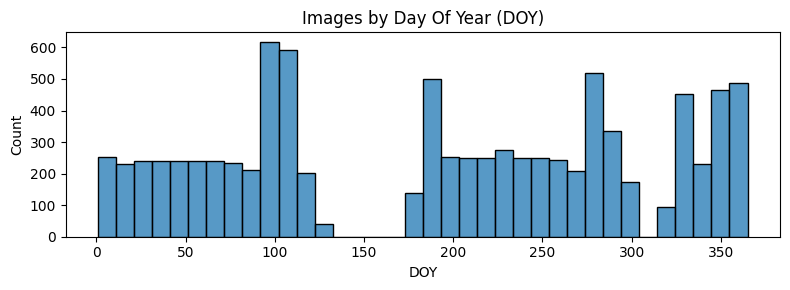

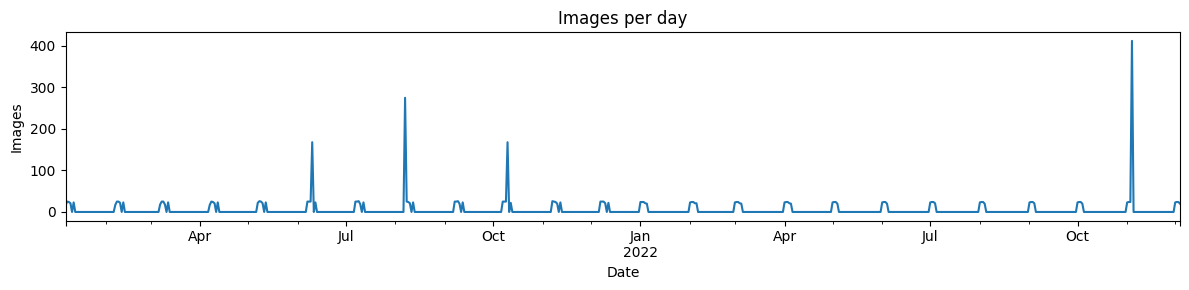

In [4]:
n_images = len(df_metadata_images)
n_cams = df_metadata_images['cam'].nunique()
images_per_cam = df_metadata_images['cam'].value_counts()

print(f"Total images: {n_images}")
print(f"Total cameras: {n_cams}")

print("\n")

print("Top 10 cameras by image count:")
display(images_per_cam.head(10))

print("Worst 10 cameras by image count:")
display(images_per_cam.tail(10))

print("-"*20)

if 'cis_prod_fold' in df_metadata_images.columns:
    fold_counts = df_metadata_images['cis_prod_fold'].value_counts(dropna=False).sort_index()
    print('Validation fold distribution:')
    display(fold_counts)

print("-"*20)

_, _, test_df = make_cis_prod_splits(df_metadata_images, fold_index=1)

print("Test holdout distribution:")
counts = test_df['weather'].value_counts(normalize=True).sort_index()
counts = counts.reindex(range(len(CLASS_NAMES)), fill_value=0)
counts.index = [CLASS_NAMES[i] for i in counts.index]
print(f"  test size: {len(test_df)}")
display(counts)

print("-"*20)

print('`cis_prod_fold` holdout distribution:')
if 'cis_prod_fold' in df_metadata_images.columns:
    for fold in range(1, 6):
        print(f"\nFOLD {fold}")
        try:
            train_df, val_df, _ = make_cis_prod_splits(df_metadata_images, fold_index=fold)
        except Exception as e:
            print(f"  Error creating splits for fold {fold}: {e}")
            continue

        for name, split_df in [('Train', train_df), ('Val', val_df)]:
            counts = split_df['weather'].value_counts(normalize=True).sort_index()
            counts = counts.reindex(range(len(CLASS_NAMES)), fill_value=0)
            counts.index = [CLASS_NAMES[i] for i in counts.index]
            print(f"{name} size: {len(split_df)}")
            display(counts)

print("-"*20)

print("Temporal distributions:")
if 'DateTime' in df_metadata_images.columns:
    dt_col = 'DateTime'
elif 'DateTimeOriginal' in df_metadata_images.columns:
    dt_col = 'DateTimeOriginal'
else:
    dt_col = None

df_time = df_metadata_images.copy()
if dt_col is not None:
    df_time['DateTime_parsed'] = pd.to_datetime(df_time[dt_col], errors='coerce')
else:
    df_time['DateTime_parsed'] = pd.NaT

if 'Hour' in df_time.columns:
    plt.figure(figsize=(8,3))
    sns.histplot(df_time['Hour'].dropna().astype(int), bins=24)
    plt.title('Images by Hour of Day')
    plt.xlabel('Hour')
    plt.tight_layout()
    plt.show()
else:
    print('Hour column not present')

if 'DOY' in df_time.columns:
    plt.figure(figsize=(8,3))
    sns.histplot(df_time['DOY'].dropna().astype(int), bins=36)
    plt.title('Images by Day Of Year (DOY)')
    plt.xlabel('DOY')
    plt.tight_layout()
    plt.show()
else:
    print('DOY column not present')

if df_time['DateTime_parsed'].notna().any():
    per_day = df_time.set_index('DateTime_parsed').resample('D').size()
    plt.figure(figsize=(12,3))
    per_day.plot()
    plt.title('Images per day')
    plt.xlabel('Date')
    plt.ylabel('Images')
    plt.tight_layout()
    plt.show()


# TODO: commentare

# camera non bilanciate
# classi non bilanciate
# non c'è leakage tra fold anche se c'è una piccola varianza di percentuale di occorrenza per ogni classe, non tutti i fold hanno perfettamente lo stesso bilanciamento
# il numero di immagini per ora del giorno(considerando tutto il dataset) è abbstanza bilanciato
# il numero di immagini per DOY non è troppo bilanciato, mancano immagini per alcuni giorni dell'anno, attorno al 150esimo, mentre il periodo attorno al 100esimo giorno e attorno alla fine dell'anno sono overrappresentatit, sicuramnete per rappresentare meglio hail e snow
# ci sono picchi di immagini scattate in alcuni giorni, sicuramente dovute ai periodi in cui sono state deployate le camere, questi valori sono simili al risultato di immagini per DOY

## Load dataset

Because the dataset identifies images using only their file names (without paths), and images are organized in subdirectories by class ID, a function is needed to resolve the full image paths based on the `DatasetOutFileName` and the directory structure.

In [5]:
load_local_images = False

if load_local_images:

    file_map = defaultdict(list)
    for root, _, files in os.walk(IMAGES_DIR):
        for fname in files:
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                file_map[fname].append(os.path.abspath(os.path.join(root, fname)))

    def resolve_filename(fname):
        hits = file_map.get(fname)
        return hits[0] if hits else None

    df_metadata_images['DatasetAbsPath'] = df_metadata_images['DatasetOutFileName'].map(resolve_filename)

    TARGET_SIZE = 518

    def process_image_png(args):
        src_path, rel_path = args
        if not src_path: return None
        
        dst_path = os.path.join(IMAGES_DIR_LOCAL, os.path.splitext(rel_path)[0] + ".png")
        
        if os.path.exists(dst_path):
            return dst_path
            
        try:
            os.makedirs(os.path.dirname(dst_path), exist_ok=True)
            with Image.open(src_path) as img:
                img = img.convert('RGB')
                img_resized = img.resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.LANCZOS)
                img_resized.save(dst_path, "PNG", compress_level=3)
            return dst_path
        except Exception as e:
            return None

    tasks = []
    for _, row in df_metadata_images.iterrows():
        tasks.append((row['DatasetAbsPath'], row['DatasetOutFileName']))

    with ProcessPoolExecutor(max_workers=8) as executor:
        local_paths = list(tqdm(executor.map(process_image_png, tasks), total=len(tasks)))

    df_metadata_images['DatasetLocalPath'] = local_paths
    df_metadata_images.to_csv(IMAGES_METADATA_CSV_LOCAL, index=False)
else:
    df_metadata_images = pd.read_csv(IMAGES_METADATA_CSV_LOCAL)

In [6]:
df_metadata_images.head()

,DatasetOutFileName,label_sample,Region,cam,DateTimeOriginal,DateTime,DOY,Hour,Minute,Temperature,Flash,ExposureTime,weather,weather_desc,cis_fold,trans_fold,holdout,cis_prod_fold,DatasetAbsPath,DatasetLocalPath
0,000001.JPG,systematic,ZA,SA16,2022:01:12 21:01:12,12/01/2022 21:01,12,21,1,10,1,0.065986,0,background,2,4,False,4,/mnt/synas/ngb/AI_DATASETS/zenodo_10137731_wea...,./dataset_local/000001.png
1,000002.JPG,strategic,ZA,SA07,2021:12:25 03:03:27,25/12/2021 03:03,359,3,3,2,1,0.065986,3,hail,4,2,False,1,/mnt/synas/ngb/AI_DATASETS/zenodo_10137731_wea...,./dataset_local/000002.png
2,000003.JPG,systematic,ZA,SA06,2022:04:01 15:00:27,01/04/2022 15:00,91,15,0,6,0,0.004672,1,sunshine,1,1,False,1,/mnt/synas/ngb/AI_DATASETS/zenodo_10137731_wea...,./dataset_local/000003.png
3,000004.JPG,strategic,CH,C02,2021:09:04 01:00:01,04/09/2021 01:00,247,1,0,7,1,0.065986,0,background,6,6,True,5,/mnt/synas/ngb/AI_DATASETS/zenodo_10137731_wea...,./dataset_local/000004.png
4,000005.JPG,systematic,CH,C17,2021:08:31 09:01:31,31/08/2021 09:01,243,9,1,5,0,0.002625,1,sunshine,2,3,False,5,/mnt/synas/ngb/AI_DATASETS/zenodo_10137731_wea...,./dataset_local/000005.png


In [7]:
class WeatherDataset(Dataset):
    def __init__(self, metadata, transform=None, local=True):
        self.metadata = metadata.reset_index(drop=True)
        self.image_paths = self.metadata['DatasetLocalPath'].tolist() if local else self.metadata['DatasetAbsPath'].tolist()
        self.labels = self.metadata['weather'].tolist()
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        max_retries = 5
        
        for attempt in range(max_retries):
            try:
                image = Image.open(image_path).convert("RGB")
                
                if self.transform:
                    image = self.transform(image)
                
                label = self.labels[idx]
                return image, label
                
            except Exception as e:
                if attempt == 0:
                    print(f"Error loading {image_path}: {e}")
                # try a different random sample
                idx = np.random.randint(0, len(self))
                image_path = self.image_paths[idx]
        
        raise RuntimeError(f"Failed to load any valid image after {max_retries} attempts")


## Visualizing some example images from the dataset

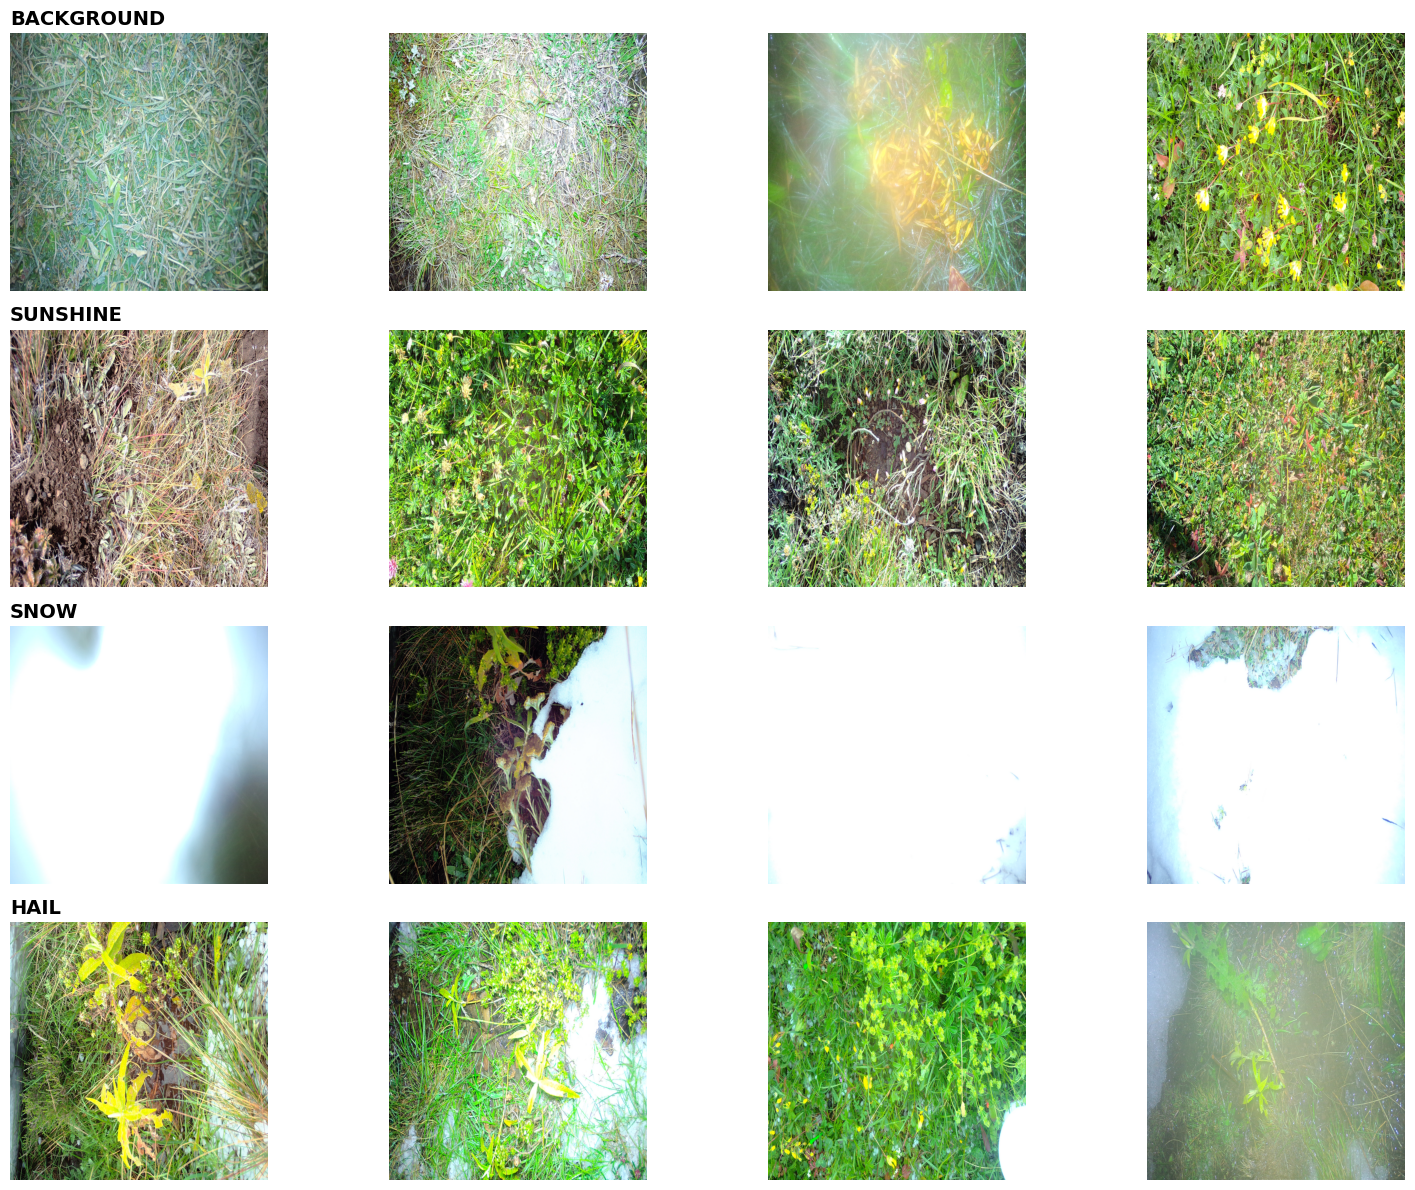

In [8]:
random.seed(SEED)

fig, axes = plt.subplots(len(CLASS_NAMES), 4, figsize=(16, 3*len(CLASS_NAMES)))

for row_idx, class_name in enumerate(CLASS_NAMES):
    cls_df = df_metadata_images[df_metadata_images['weather'] == row_idx]
    samples = cls_df.sample(n=4, replace=(len(cls_df) < 4), random_state=SEED)
    
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_idx, col_idx]
        
        path = row.get('DatasetLocalPath')

        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(class_name.upper(), fontsize=14, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()


## Training and evaluating MobileNet models

# TODO: sistemare

Parlare di augmentations usate, hyperparametri, ecc. confrontandole con quelle usate nel paper, parlare dello stesso approcio a due step(warm-up + full fine-tuning) provando iterazioni successive di mobile net con qualche aggiunta

To train these new versions of MobileNet, I used the same hyperparameters used in the original paper, things that are changed are:
- `finetune_epochs`: originally set to 200, now 30 with early stopping
- `patience`: originally set to 50, now 5
- `augmentations`: the original paper only used random horizontal and vertical flip of the image, combined with 45° degrees rotation. Instead, additionally to augmentations used in the image, I used also:
    - `RandomCrop`, to increase augmentation.
    - `ColorJitter`, to add a small variations in the image illuminations, with the goal of simulating not perfect camera quality and making a bit more difficult the classification, considering that these classes are strictly tailored to the colors seen in the images.
    - `Normalization`, to match the one used in pre-training of the MobileNet models used in this experiment.

Also, in the training **gradient scaling** and **autocast** has been used, to .... TODO: continuare

In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(dataloader, desc='train', leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        with torch.amp.autocast(enabled=(device.type=='cuda'), device_type=device.type):
            logits = model(images)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': running_loss/total, 'acc': correct/total})
    return running_loss/total, correct/total

def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='eval', leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': running_loss/total, 'acc': correct/total})
    return running_loss/total, correct/total

def save_checkpoint(model, optimizer, epoch, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, path)


### Defining training constants

In [10]:
NUM_CLASSES = len(CLASS_NAMES)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE = 128
WARMUP_EPOCHS = 5      
FINETUNE_EPOCHS = 30   
LR_WARMUP = 1e-3       
LR_FINETUNE = 1e-5     
PATIENCE = 5

MNV3_CARD = 'timm/mobilenetv3_small_100.lamb_in1k'
MNV3_FOLDER_RES = 'mobilenetv3_results/'

MNV4_CARD = 'timm/mobilenetv4_conv_small.e2400_r224_in1k'
MNV4_FOLDER_RES = 'mobilenetv4_results/'

### MobileNet V3 small

In [11]:
data_config_mnv3 = timm.data.resolve_data_config({}, model=MNV3_CARD)

print(f'{MNV3_CARD} data config:\n {data_config_mnv3}')

img_size_mnv3 = data_config_mnv3['input_size'][1]

print(f'Using image size: {img_size_mnv3}\n')

transform_train_mnv3 = T.Compose([
    T.Resize(int(img_size_mnv3 / data_config_mnv3['crop_pct']), interpolation=T.InterpolationMode.BICUBIC), # from model data config
    T.RandomCrop(img_size_mnv3), # added by me to increase data augmentation
    T.RandomHorizontalFlip(p=0.5), # as in the original paper
    T.RandomVerticalFlip(p=0.5), # as in the original paper
    T.RandomRotation(degrees=45, interpolation=T.InterpolationMode.BICUBIC), # as in the original paper
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # added by me to increase data augmentation
    T.ToTensor(), # required
    T.Normalize(mean=data_config_mnv3['mean'], std=data_config_mnv3['std']) # required to be uniform with model pre-training
])

transforms_val_mnv3 = T.Compose([
    T.Resize(img_size_mnv3, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(img_size_mnv3),
    T.ToTensor(),
    T.Normalize(mean=data_config_mnv3['mean'], std=data_config_mnv3['std'])
])

results_mobilenetv3 = []

for fold_idx in range(5):
    print(f'{"#"*20} FOLD {fold_idx+1} {"#"*20}\n')
    train_df, val_df, test_df = make_cis_prod_splits(df_metadata_images, fold_index=fold_idx+1)
    
    train_ds = WeatherDataset(train_df, transform=transform_train_mnv3)
    val_ds = WeatherDataset(val_df, transform=transforms_val_mnv3)
    test_ds = WeatherDataset(test_df, transform=transforms_val_mnv3)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                              num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                           num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                            num_workers=4, pin_memory=True, persistent_workers=True)
    
    model = timm.create_model(MNV3_CARD, pretrained=True, num_classes=NUM_CLASSES, cache_dir="models-cache")
    model.to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

    # WARM-UP
    print(f"Warm-up: {WARMUP_EPOCHS} epochs\n")

    for name, param in model.named_parameters():
        if 'head' not in name:
            param.requires_grad = False

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_WARMUP)
    
    for epoch in range(WARMUP_EPOCHS):
        train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, DEVICE)
        print(f'  [Warm-up {epoch+1}/{WARMUP_EPOCHS}] Val Acc: {val_acc:.4f}\n')

    # FULL FINE-TUNING
    print(f"Full fine-tuning: max {FINETUNE_EPOCHS} epochs\n")
    
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=LR_FINETUNE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

    best_val_acc = 0.0
    patience_it = 0

    for epoch in range(FINETUNE_EPOCHS):
        print(f'Epoch {epoch+1}/{FINETUNE_EPOCHS}')
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, DEVICE)
        print(f'\tTrain loss={train_loss:.4f} acc={train_acc:.4f} | Validation loss={val_loss:.4f} acc={val_acc:.4f}\n')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_it = 0
            save_checkpoint(model, optimizer, epoch, os.path.join(MNV3_FOLDER_RES, f'fold_{fold_idx}_best.pt'))
            print(f'\t\tNew best validation accuracy: {best_val_acc:.4f}\n')
        else:
            patience_it += 1
            print(f'\t\tNo improvements in validation accuracy {val_acc:.4f} (Best: {best_val_acc:.4f})\n')
            
        scheduler.step()

        if patience_it >= PATIENCE:
            print(f'Early stopping triggered\n')
            break

    # TEST
    test_loss, test_acc = eval_one_epoch(model, test_loader, criterion, DEVICE)
    print(f'Fold {fold_idx+1} test loss={test_loss:.4f} acc={test_acc:.4f}\n')
    results_mobilenetv3.append({'fold': fold_idx+1, 'test_loss': test_loss, 'test_acc': test_acc})

    del model, optimizer, scaler, scheduler, criterion
    torch.cuda.empty_cache()

df_results_mobilenetv3 = pd.DataFrame(results_mobilenetv3)
print('All folds results:\n')
print(df_results_mobilenetv3)
print('\nMean:')
print(df_results_mobilenetv3.mean(numeric_only=True))

df_results_mobilenetv3.to_csv(os.path.join(MNV3_FOLDER_RES, 'fold_results.csv'))

timm/mobilenetv3_small_100.lamb_in1k data config:
 {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}
Using image size: 224

#################### FOLD 1 ####################

Warm-up: 5 epochs

Warm-up: 5 epochs



  [Warm-up 1/5] Val Acc: 0.8261



  [Warm-up 2/5] Val Acc: 0.8424



  [Warm-up 3/5] Val Acc: 0.8822



  [Warm-up 4/5] Val Acc: 0.8900



...

  [Warm-up 2/5] Val Acc: 0.8749



  [Warm-up 3/5] Val Acc: 0.8853



  [Warm-up 4/5] Val Acc: 0.8982



  [Warm-up 5/5] Val Acc: 0.9142

Full fine-tuning: max 30 epochs

Epoch 1/30


KeyboardInterrupt: 

### MobileNet v4 small

In [ ]:
data_config_mnv4 = timm.data.resolve_data_config({}, model=MNV4_CARD)

print(f'{MNV4_CARD} data config:\n {data_config_mnv4}')

img_size_mnv4 = data_config_mnv4['input_size'][1]
print(f'Using image size: {img_size_mnv4}\n')

transform_train_mnv4 = T.Compose([
    T.Resize(int(img_size_mnv4 / data_config_mnv4['crop_pct']), interpolation=T.InterpolationMode.BICUBIC), # from model data config
    T.RandomCrop(img_size_mnv4), # added by me to increase data augmentation
    T.RandomHorizontalFlip(p=0.5), # as in the original paper
    T.RandomVerticalFlip(p=0.5), # as in the original paper
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # added by me to increase data augmentation
    T.ToTensor(), # required
    T.Normalize(mean=data_config_mnv4['mean'], std=data_config_mnv4['std']) # required to be uniform with model pre-training
])

transforms_val_mnv4 = T.Compose([
    T.Resize(img_size_mnv4, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(img_size_mnv4),
    T.ToTensor(),
    T.Normalize(mean=data_config_mnv4['mean'], std=data_config_mnv4['std'])
])

results_mobilenetv4 = []

for fold_idx in range(5):
    print(f'{"#"*20} FOLD {fold_idx+1} {"#"*20}\n')
    train_df, val_df, test_df = make_cis_prod_splits(df_metadata_images, fold_index=fold_idx+1)
    
    train_ds = WeatherDataset(train_df, transform=transform_train_mnv4)
    val_ds = WeatherDataset(val_df, transform=transforms_val_mnv4)
    test_ds = WeatherDataset(test_df, transform=transforms_val_mnv4)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                              num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                           num_workers=4, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                            num_workers=4, pin_memory=True, persistent_workers=True)
    
    model = timm.create_model(MNV4_CARD, pretrained=True, num_classes=NUM_CLASSES, cache_dir="models-cache")
    model.to(DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type=='cuda'))

    # WARM-UP
    print(f"Warm-up: {WARMUP_EPOCHS} epochs\n")

    # unfreezing only the head
    for name, param in model.named_parameters():
        if 'head' not in name:
            param.requires_grad = False

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_WARMUP)
    
    for epoch in range(WARMUP_EPOCHS):
        train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, DEVICE)
        print(f'  [Warm-up {epoch+1}/{WARMUP_EPOCHS}] Val Acc: {val_acc:.4f}\n')

    # FULL FINE-TUNING
    print(f"Full fine-tuning: max {FINETUNE_EPOCHS} epochs\n")
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=LR_FINETUNE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

    best_val_acc = 0.0
    patience_it = 0

    for epoch in range(FINETUNE_EPOCHS):
        print(f'Epoch {epoch+1}/{FINETUNE_EPOCHS}')
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, DEVICE)
        print(f'\tTrain loss={train_loss:.4f} acc={train_acc:.4f} | Validation loss={val_loss:.4f} acc={val_acc:.4f}\n')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_it = 0
            save_checkpoint(model, optimizer, epoch, os.path.join(MNV4_FOLDER_RES, f'fold_{fold_idx}_best.pt'))
            print(f'\t\tNew best validation accuracy: {best_val_acc:.4f}\n')
        else:
            patience_it += 1
            print(f'\t\tNo improvements in validation accuracy {val_acc:.4f} (Best: {best_val_acc:.4f})\n')
            
        scheduler.step()

        if patience_it >= PATIENCE:
            print(f'Early stopping triggered\n')
            break

    # TEST
    test_loss, test_acc = eval_one_epoch(model, test_loader, criterion, DEVICE)
    print(f'Fold {fold_idx+1} test loss={test_loss:.4f} acc={test_acc:.4f}\n')
    results_mobilenetv4.append({'fold': fold_idx+1, 'test_loss': test_loss, 'test_acc': test_acc})

    del model, optimizer, scaler, scheduler, criterion
    torch.cuda.empty_cache()

df_results_mobilenetv4 = pd.DataFrame(results_mobilenetv4)
print('All folds results:\n')
print(df_results_mobilenetv4)
print('\nMean:')
print(df_results_mobilenetv4.mean(numeric_only=True))

df_results_mobilenetv4.to_csv(os.path.join(MNV4_FOLDER_RES, 'fold_results.csv'))


## Comparing best obtained models

dire che ho preso i due migliori according to the test set

### MobileNet v3 small evaluation

We can see that ...

In [ ]:
# TODO: load pt

# TODO: run predictions on test set

# TODO: print classification report

### MobileNet v4 small evaluation

We can see that ...

## Conclusions

